These are the updated empirical results for the paper, for Chris, David, and
David. This is an interim update. It includes paper-ready results, checks that
are still in progress, and a few diagnostics that I would keep out of the paper
unless they survive follow-up.

The paper asks how large the simulation budget $N$ must be, relative to the
number of observations $n$ and the problem dimension $d$ (summaries plus
parameters), for NPE to recover the posterior. The general smooth-posterior
case gives a dimension dependence that is too costly for the examples here. The
Bernstein-von Mises case gives the practical scaling, $N \gg d^2 n$. I have
kept that framing in the plots below.

The empirical setup compares two NPE families. Flow-NPE uses a normalising-flow
conditional density estimator. Gaussian-NPE uses a single conditional Gaussian
(mean and covariance both neural-parametrised), which is the $k=1$ case of the
Gaussian-mixture-of-experts family the paper's appendix analyses. In the BvM
regime the posterior is asymptotically Gaussian, so Gaussian-NPE has the
matching inductive bias, and a residual gap to the reference reads as finite-$N$
approximation error rather than a family mismatch. This is the framing I am
using to interpret the GNK and MA(2) results below.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

DATA = Path("data")
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3, "grid.linewidth": 0.5,
})
C_FLOW, C_GAUSS, C_REF = "#1f77b4", "#d62728", "#444444"
C_BSL, C_ROBUST, C_REJ = "#2ca02c", "#9467bd", "#ff7f0e"
C_DELTA1, C_TIMEOUT = "#2ca02c", "#7f7f7f"
BUDGETS = ["N=n", "N=n log(n)", "N=n^(3/2)", "N=n^2"]
BUDGET_MATH = ["n", r"n\log n", r"n^{3/2}", r"n^2"]
N_OBS = [100, 500, 1000, 5000]
METHOD_NAME = {"flow_npe": "flow-NPE", "gaussian_npe": "Gaussian-NPE"}
GNK_TRUE = {"A": 3.0, "B": 1.0, "g": 2.0, "k": 0.5}
PARAM_MATH = {"A": "A", "B": "B", "g": "g", "k": "k",
              "lambda": r"\lambda", "sigma": r"\sigma", "xi": r"\xi"}

# Stereological

The stereological model stays first because it is the motivating example in the
paper. It has three parameters $(\lambda, \sigma, \xi)$ and four summaries, so
$d=7$. The reference is SMC-ABC. With this low dimension, the budget asked for
by the $d^2 n$ scaling is modest, and $N$ at or above $n^{3/2}$ is already
enough for good coverage.

**Coverage.** Monte Carlo coverage of the 95% credible intervals, computed over
100 simulated datasets and averaged over the three parameters. The
$n=5000,\ N=n^2$ cell is not run because the simulation cost is too high.

In [2]:
cov = pd.read_csv(DATA / "stereological_coverage.csv")
cov = cov[cov.N_label.isin(BUDGETS)].copy()
cov["method"] = cov["method"].map(METHOD_NAME)
cov_avg = (cov.groupby(["method", "N_label", "n"])["coverage_95_mean"]
              .mean().reset_index())
cov_avg["N_label"] = pd.Categorical(cov_avg["N_label"], categories=BUDGETS,
                                    ordered=True)
cov_table = cov_avg.pivot_table(index=["method", "N_label"], columns="n",
                                values="coverage_95_mean", observed=True)
cov_table = cov_table.sort_index()[N_OBS].round(3)
cov_table = cov_table.where(cov_table.notna(), "")
cov_table.index.names = ["method", "budget"]
cov_table.columns.name = "n"
cov_table

n                         100    500    1000   5000
method       budget                                
Gaussian-NPE N=n         0.996  0.999  0.987  0.997
             N=n log(n)  0.992  0.975  0.981  0.989
             N=n^(3/2)   0.973  0.982  0.987  0.992
             N=n^2       0.986  0.975  0.983       
flow-NPE     N=n         0.929  0.986  0.997  0.999
             N=n log(n)  0.984  0.993  0.994  0.992
             N=n^(3/2)   0.992  0.986  0.982  0.974
             N=n^2       0.983  0.965  0.965

**Posterior-mean bias.** Boxplots of the per-seed posterior-mean bias, by
parameter and observation count, with flow-NPE and Gaussian-NPE side by side at
each budget. The dashed line is zero bias.

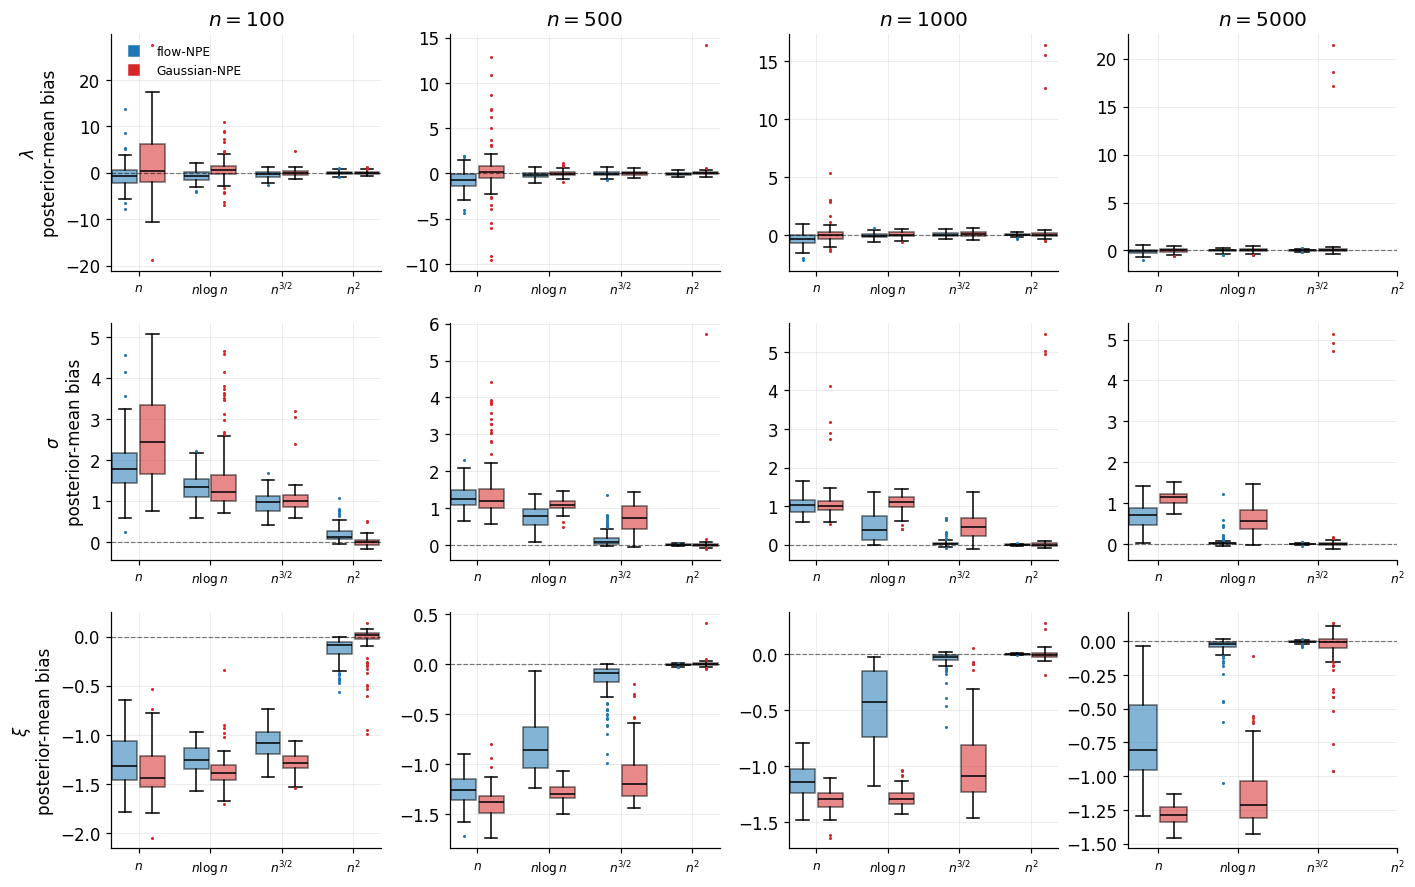

In [3]:
bias = pd.read_csv(DATA / "stereological_bias_by_seed.csv")
bias = bias[bias.N_label.isin(BUDGETS)]
params = ["lambda", "sigma", "xi"]
fig, axes = plt.subplots(3, 4, figsize=(13, 8.2))
for r, param in enumerate(params):
    for c, n in enumerate(N_OBS):
        ax = axes[r, c]
        for b, bud in enumerate(BUDGETS):
            for k, (raw, color) in enumerate([("flow_npe", C_FLOW),
                                              ("gaussian_npe", C_GAUSS)]):
                vals = bias[(bias["param"] == param) & (bias.n == n)
                            & (bias.N_label == bud)
                            & (bias.method == raw)]["mean_bias"].dropna().values
                if len(vals) == 0:
                    continue
                bp = ax.boxplot([vals], positions=[b * 2.6 + k], widths=0.9,
                                patch_artist=True,
                                flierprops=dict(marker=".", markersize=2,
                                                markerfacecolor=color,
                                                markeredgecolor=color))
                for patch in bp["boxes"]:
                    patch.set_facecolor(color)
                    patch.set_alpha(0.55)
                for med in bp["medians"]:
                    med.set_color("black")
        ax.axhline(0, color="black", ls="--", lw=0.8, alpha=0.5)
        ax.set_xticks([b * 2.6 + 0.5 for b in range(4)])
        ax.set_xticklabels([f"${b}$" for b in BUDGET_MATH], fontsize=8)
        if r == 0:
            ax.set_title(f"$n = {n}$")
        if c == 0:
            ax.set_ylabel(f"${PARAM_MATH[param]}$\nposterior-mean bias")
axes[0, 0].plot([], [], "s", color=C_FLOW, label="flow-NPE")
axes[0, 0].plot([], [], "s", color=C_GAUSS, label="Gaussian-NPE")
axes[0, 0].legend(frameon=False, fontsize=8, loc="upper left")
fig.tight_layout()
plt.show()

**Posterior overlay for $\lambda$** (a single simulated dataset, $n=1000$,
seed 1). The NPE posterior at each budget is shown against the SMC-ABC
benchmark. The dashed line is the true $\lambda$.

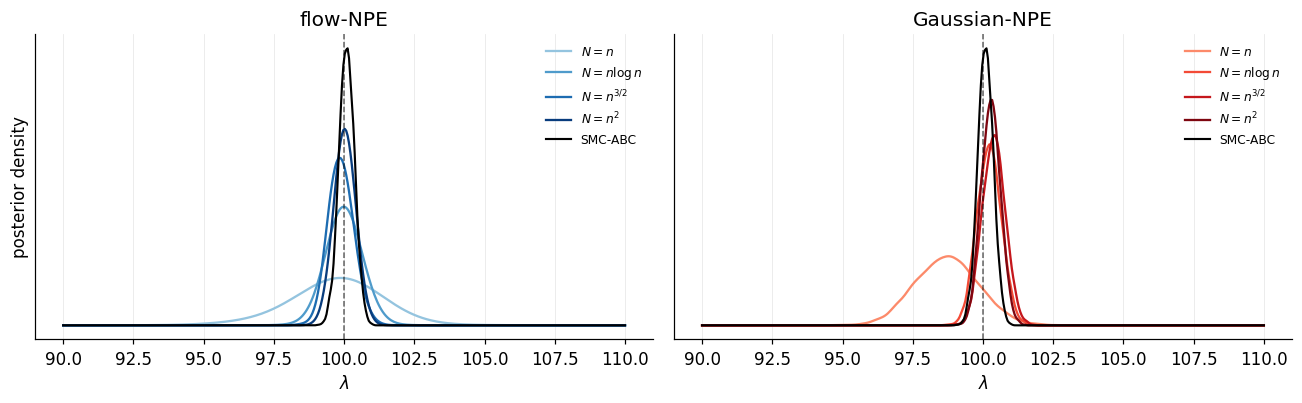

In [4]:
ster_ov = pd.read_csv(DATA / "stereological_posterior_overlay.csv")
lam = ster_ov[ster_ov.param == "lambda"]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharex=True)
specs = [("flow_npe", "flow-NPE", plt.cm.Blues),
         ("gaussian_npe", "Gaussian-NPE", plt.cm.Reds)]
for ax, (raw, mname, cmap) in zip(axes, specs):
    shades = cmap(np.linspace(0.4, 0.95, len(BUDGETS)))
    for bud, shade, lab in zip(BUDGETS, shades, BUDGET_MATH):
        s = lam[(lam.method == raw) & (lam.N_label == bud)].sort_values("x")
        ax.plot(s.x, s.density, color=shade, label=f"$N={lab}$")
    a = lam[lam.method == "abc_smc"].sort_values("x")
    ax.plot(a.x, a.density, color="black", lw=1.4, label="SMC-ABC")
    ax.axvline(100.0, color="black", ls="--", lw=1, alpha=0.6)
    ax.set_title(mname)
    ax.set_xlabel(r"$\lambda$")
    ax.set_yticks([])
    ax.legend(frameon=False, fontsize=8)
axes[0].set_ylabel("posterior density")
fig.tight_layout()
plt.show()

Coverage is near or above the nominal level. Bias falls as the budget grows for
both methods. flow-NPE reaches small bias at a lower budget than Gaussian-NPE,
which still shows visible $\sigma$ and $\xi$ bias at smaller budgets for the
larger sample sizes. In the $\lambda$ overlay both methods concentrate onto the
true value as $N$ grows.

A note on the reference. The stereological reference is the SMC-ABC posterior. I
am considering an upgrade for the next iteration, exploiting the exact Poisson
count factorisation to condition $\lambda$ on $K$ analytically (truncated
Gamma), then run SMC-ABC only on $(\sigma, \xi)$. Together with a
Mahalanobis-distance schedule, a tighter tolerance ladder, and at least three
independent replicates per cell, this would give a stronger reference for the
KL claim. Not done yet.

# g-and-k

The g-and-k model has four parameters $(A, B, g, k)$ and is summarised by seven
octiles, so $d=11$. The reference posterior is from NUTS, conditioned on the
same seven octiles. This section now separates the paper-grid result from the
diagnostics prompted by the concern that the GNK NPE posteriors were not close
enough to the reference at the headline cell.

**KL from the reference posterior.** Median over seeds, shown as
flow-NPE / Gaussian-NPE, across observation count $n$ and budget $N$. Lower is
better. The moment-matched Gaussian row measures how close the reference
posterior is to Gaussian.

In [5]:
gnk = pd.read_csv(DATA / "gnk_kl_flow_vs_gaussian.csv")
grid = gnk[gnk.standard_paper_grid == 1].copy()
grid["entry"] = grid.apply(
    lambda r: f"{r.flow_theta_kl_median:.2f} / {r.gaussian_theta_kl_median:.2f}",
    axis=1)
kl_table = grid.pivot(index="N_label", columns="n", values="entry")
kl_table = kl_table.reindex(BUDGETS)[N_OBS]

oracle = pd.read_csv(DATA / "gnk_theta_oracle_by_n.csv").set_index("n")
kl_table.loc["moment-matched Gaussian"] = [
    f"{oracle.loc[n, 'K_theta_star_median']:.4f}" for n in N_OBS]
kl_table.index.name = "budget"
kl_table.columns.name = "n"
display(kl_table)

ci = pd.read_csv(DATA / "gnk_paper_grid_bootstrap_ci.csv")
ci = ci[ci.N_label.isin(BUDGETS)].copy()
ci["budget"] = pd.Categorical(ci.N_label, categories=BUDGETS, ordered=True)
ci["flow median (90% CI)"] = ci.apply(
    lambda r: f"{r.flow_median:.2f} [{r.flow_ci05:.2f}, {r.flow_ci95:.2f}]",
    axis=1)
ci["Gaussian median (90% CI)"] = ci.apply(
    lambda r: f"{r.gaussian_median:.2f} [{r.gaussian_ci05:.2f}, {r.gaussian_ci95:.2f}]",
    axis=1)
ci["paired Gaussian-flow median (90% CI)"] = ci.apply(
    lambda r: (f"{r.gaussian_minus_flow_median:.2f} "
               f"[{r.gaussian_minus_flow_ci05:.2f}, "
               f"{r.gaussian_minus_flow_ci95:.2f}]"),
    axis=1)
ci = ci.sort_values(["n", "budget"]).reset_index(drop=True)
ci_table = ci[["n", "N_label", "seed_count", "flow median (90% CI)",
               "Gaussian median (90% CI)",
               "paired Gaussian-flow median (90% CI)"]]
ci_table

n,100,500,1000,5000
budget,,,,
N=n,9.62 / 9.56,9.06 / 8.35,8.86 / 9.14,6.87 / 7.69
N=n log(n),8.12 / 6.97,6.39 / 7.06,5.72 / 5.96,4.09 / 4.51
N=n^(3/2),6.73 / 6.17,4.40 / 4.59,3.65 / 3.87,2.59 / 2.98
N=n^2,4.33 / 4.09,2.04 / 2.76,1.87 / 2.48,2.22 / 2.67
moment-matched Gaussian,0.6698,0.0995,0.0487,0.0055


,n,N_label,seed_count,flow median (90% CI),Gaussian median (90% CI),paired Gaussian-flow median (90% CI)
0,100,N=n,101,"9.62 [9.34, 10.11]","9.56 [8.87, 9.92]","-0.33 [-0.70, 0.19]"
1,100,N=n log(n),101,"8.12 [7.83, 8.54]","6.97 [6.50, 7.41]","-1.01 [-1.40, -0.62]"
2,100,N=n^(3/2),101,"6.73 [6.61, 6.89]","6.17 [5.93, 6.30]","-0.61 [-0.99, -0.33]"
3,100,N=n^2,101,"4.33 [4.20, 4.58]","4.09 [3.99, 4.24]","-0.25 [-0.50, -0.17]"
4,500,N=n,101,"9.06 [8.82, 9.49]","8.35 [8.22, 8.57]","-0.71 [-1.19, -0.42]"
5,500,N=n log(n),101,"6.39 [6.16, 6.69]","7.06 [6.97, 7.14]","0.63 [0.43, 0.87]"
6,500,N=n^(3/2),101,"4.40 [4.32, 4.58]","4.59 [4.54, 4.71]","0.02 [-0.18, 0.26]"
7,500,N=n^2,101,"2.04 [1.97, 2.17]","2.76 [2.64, 2.96]","0.67 [0.56, 0.79]"
8,1000,N=n,101,"8.86 [8.73, 9.17]","9.14 [9.00, 9.26]","0.19 [-0.14, 0.47]"
9,1000,N=n log(n),101,"5.72 [5.51, 5.90]","5.96 [5.79, 6.07]","0.31 [0.06, 0.59]"


The bootstrap intervals above use paired seed resampling. The paired difference
is useful because the two estimators share the same simulated observation at a
given seed.

**KL versus simulation budget.** Median over seeds, with the interquartile
band, one panel per $n$.

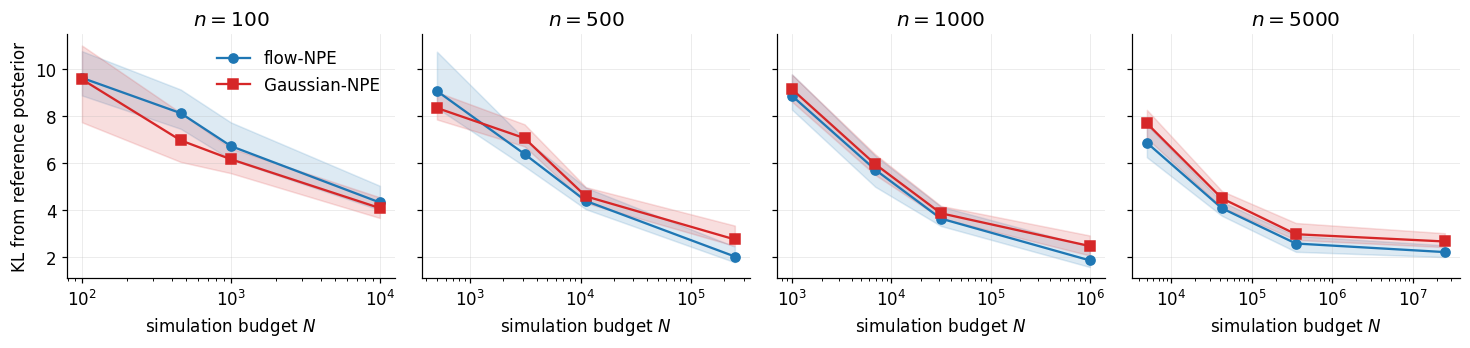

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(13.5, 3.3), sharey=True)
for ax, n in zip(axes, N_OBS):
    sub = grid[grid.n == n].sort_values("N")
    ax.plot(sub.N, sub.flow_theta_kl_median, "o-", color=C_FLOW, label="flow-NPE")
    ax.fill_between(sub.N, sub.flow_theta_kl_q25, sub.flow_theta_kl_q75,
                    color=C_FLOW, alpha=0.15)
    ax.plot(sub.N, sub.gaussian_theta_kl_median, "s-", color=C_GAUSS,
            label="Gaussian-NPE")
    ax.fill_between(sub.N, sub.gaussian_theta_kl_q25, sub.gaussian_theta_kl_q75,
                    color=C_GAUSS, alpha=0.15)
    ax.set_xscale("log")
    ax.set_title(f"$n = {n}$")
    ax.set_xlabel(r"simulation budget $N$")
axes[0].set_ylabel("KL from reference posterior")
axes[0].legend(frameon=False)
fig.tight_layout()
plt.show()

**Octile versus hexadecile summaries.** The same g-and-k experiment with seven
octile summaries ($d_s=7$) and 15 hexadecile summaries ($d_s=15$), for the two
sample sizes where the hexadecile runs exist. Only the summary dimension
changes.

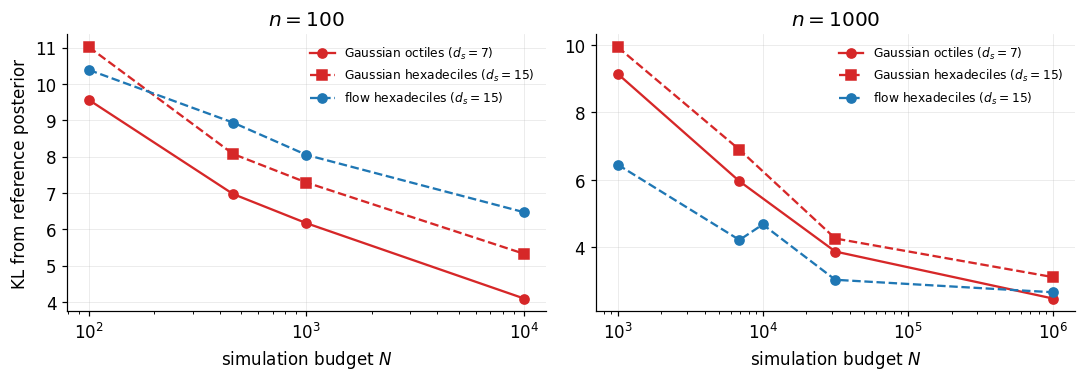

In [7]:
oct_df = grid
hex_g = pd.read_csv(DATA / "gnk_hexadecile_gaussian.csv")
hex_f = pd.read_csv(DATA / "gnk_hexadecile_flow.csv")
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, n in zip(axes, [100, 1000]):
    o = oct_df[oct_df.n == n].sort_values("N")
    ax.plot(o.N, o.gaussian_theta_kl_median, "o-", color=C_GAUSS,
            label=r"Gaussian octiles ($d_s=7$)")
    h = hex_g[hex_g.n_obs == n].sort_values("n_sims")
    ax.plot(h.n_sims, h.finite_kl_median, "s--", color=C_GAUSS,
            label=r"Gaussian hexadeciles ($d_s=15$)")
    hf = hex_f[hex_f.n_obs == n].sort_values("n_sims")
    if not hf.empty:
        ax.plot(hf.n_sims, hf.kl_median, "o--", color=C_FLOW,
                label=r"flow hexadeciles ($d_s=15$)")
    ax.set_xscale("log")
    ax.set_title(f"$n = {n}$")
    ax.set_xlabel(r"simulation budget $N$")
    ax.legend(frameon=False, fontsize=8)
axes[0].set_ylabel("KL from reference posterior")
fig.tight_layout()
plt.show()

**Posterior overlay across the scaling grid.** Each row is one $(n,N)$ cell,
with $n$ and $N$ increasing down the rows, and the columns are the four
parameters. Dashed lines mark the true values. The $n=1000$ rows use seed 36
and the $n=5000$ rows use seed 50.

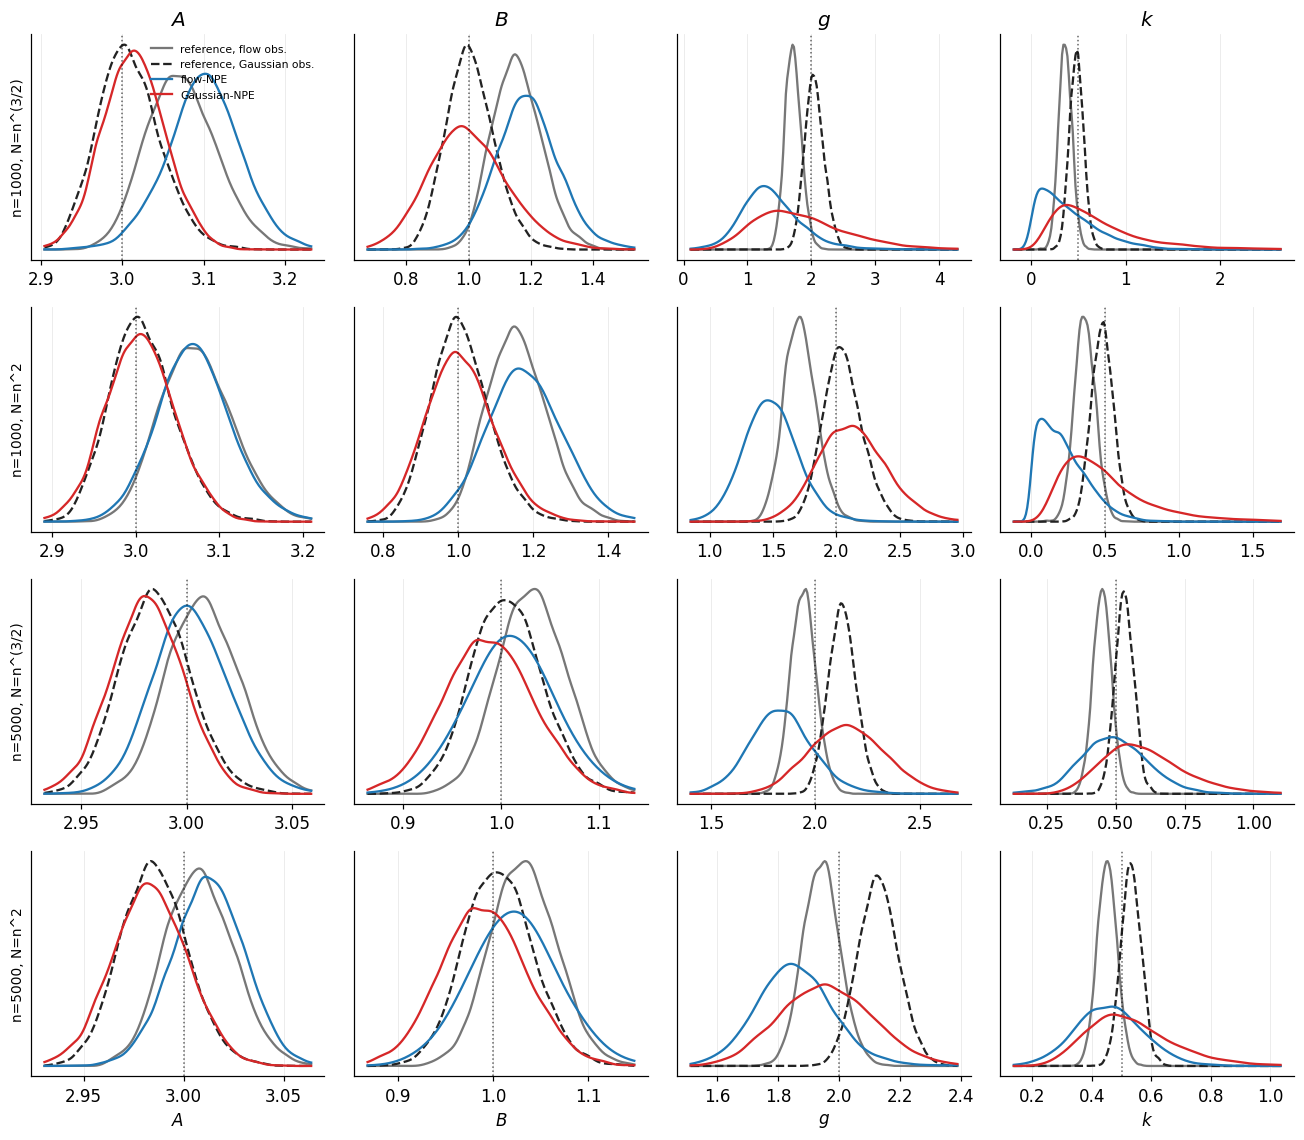

In [8]:
gnk_ov = pd.read_csv(DATA / "gnk_posterior_overlay.csv")
cells = ["n=1000, N=n^(3/2)", "n=1000, N=n^2",
         "n=5000, N=n^(3/2)", "n=5000, N=n^2"]
gnk_params = ["A", "B", "g", "k"]
overlay = [
    ("Reference (flow convention)", "#777777", "-", "reference, flow obs."),
    ("Reference (Gaussian convention)", "#222222", "--", "reference, Gaussian obs."),
    ("flow-NPE", C_FLOW, "-", "flow-NPE"),
    ("Gaussian-NPE", C_GAUSS, "-", "Gaussian-NPE"),
]
fig, axes = plt.subplots(4, 4, figsize=(12, 10.5))
for i, cell in enumerate(cells):
    for j, param in enumerate(gnk_params):
        ax = axes[i, j]
        for method, color, ls, label in overlay:
            s = gnk_ov[(gnk_ov.cell == cell) & (gnk_ov.method == method)
                       & (gnk_ov.param == param)].sort_values("x")
            if not s.empty:
                ax.plot(s.x, s.density, color=color, linestyle=ls, label=label)
        ax.axvline(GNK_TRUE[param], color="black", ls=":", lw=1, alpha=0.6)
        ax.set_yticks([])
        if i == 0:
            ax.set_title(f"${PARAM_MATH[param]}$")
        if i == 3:
            ax.set_xlabel(f"${PARAM_MATH[param]}$")
        if j == 0:
            ax.set_ylabel(cell, fontsize=9)
axes[0, 0].legend(frameon=False, fontsize=7)
fig.tight_layout()
plt.show()

**BSL diagnostic at $n=1000$, seed 0.** Chris suggested running BSL against the
GNK reference as a cross-check, since BSL uses model simulations rather than the
asymptotic summary likelihood that NUTS conditions on. At $n=1000$, seed 0, the
BSL marginal medians and standard deviations agree with the NUTS reference
within rounding, and the KL between BSL and NUTS is around 0.025 in both
directions after removing duplicate retained rows from the random-walk chain.
This supports the asymptotic summary likelihood as a reasonable stand-in for
the simulator-based partial posterior at this cell.

In [9]:
bsl = pd.read_csv(DATA / "gnk_bsl_diagnostic.csv")
bsl_table = bsl[["parameter", "NUTS median", "NUTS sd", "BSL median",
                 "BSL sd", "R-hat", "ESS", "acceptance rate"]].copy()
bsl_table[["NUTS median", "NUTS sd", "BSL median", "BSL sd",
           "R-hat", "acceptance rate"]] = (
    bsl_table[["NUTS median", "NUTS sd", "BSL median", "BSL sd",
               "R-hat", "acceptance rate"]].round(4)
)
bsl_table["ESS"] = bsl_table["ESS"].round(1)
display(bsl_table)
print("KL(BSL unique rows || NUTS):",
      round(float(bsl["KL_BSL_unique_to_NUTS"].iloc[0]), 4))
print("KL(NUTS || BSL unique rows):",
      round(float(bsl["KL_NUTS_to_BSL_unique"].iloc[0]), 4))

,parameter,NUTS median,NUTS sd,BSL median,BSL sd,R-hat,ESS,acceptance rate
0,A,3.0391,0.0399,3.0392,0.0395,1.0007,1200.6,0.2808
1,B,1.0452,0.0871,1.0498,0.0866,1.0024,1273.6,0.2808
2,g,2.1324,0.1561,2.1418,0.1593,1.0060,1091.5,0.2808
3,k,0.5537,0.0836,0.5519,0.0858,1.0016,1304.4,0.2808


KL(BSL unique rows || NUTS): 0.0224
KL(NUTS || BSL unique rows): 0.0245


**Robust standardisation diagnostic.** One thing I noticed in the GNK paper-grid
Gaussian-NPE results is that the prior-predictive simulated summaries span
several orders of magnitude under the broad $U(0,10)^4$ prior. The default
z-score standardisation puts most of the numerical scale on a few extreme
summaries and squashes the region around the observed summary. As a diagnostic,
I replaced z-score with asinh plus median/IQR. At $n=1000$, seed 0, this
dropped the joint 4-D KL from 4.70 to 1.37 nats without other changes. At
$n=5000$, seed 50, an early-stopping pilot at $N=2M$ reached KL 1.88, lower
than the same-seed standard z-score result at $N=25M$ (2.72). The shift is
consistent across parameters. The largest marginal median shift at $n=5000$ is
in $B$ at about 0.3 posterior-sd units.

I want to be careful with the framing here. This is an internal diagnostic on
the training pipeline, not a paper claim. The theory does not say anything
about standardisation, so I am treating this as a finite-$N$ implementation
question, not a method contribution.

,cell,standard z-score KL,robust KL,BSL KL,max median shift
0,"n=1000, seed=0",4.705,1.369,0.144,0.461
1,"n=5000, seed=50",2.724,1.883,NaN,0.317


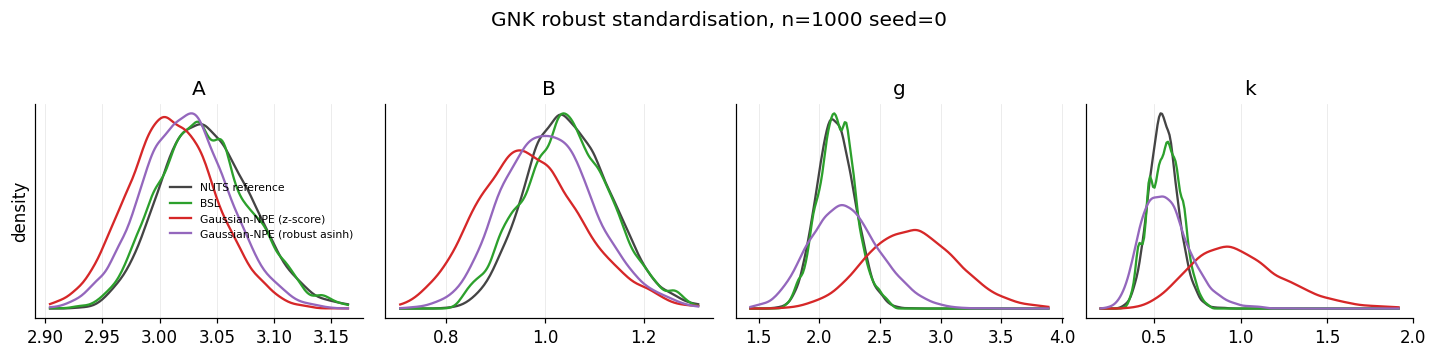

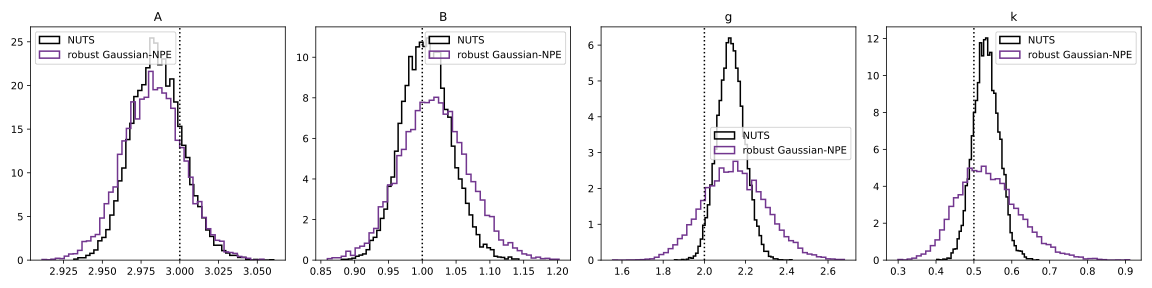

In [10]:
with open(DATA / "gnk_robust_scaling_summary.json") as fh:
    robust1000 = json.load(fh)
with open(DATA / "gnk_robust_scaling_n5000_2M_summary.json") as fh:
    robust5000 = json.load(fh)

robust_rows = [
    {
        "cell": "n=1000, seed=0",
        "standard z-score KL": robust1000["metrics"]["standard_metrics_v3"]["kl_value"],
        "robust KL": robust1000["metrics"]["robust_metrics"]["kl_value"],
        "BSL KL": robust1000["metrics"]["bsl"]["kl_value"],
        "max median shift": robust1000["median_shifts_in_nuts_sd"]["Gaussian-NPE (robust asinh)"]["max_abs"],
    },
    {
        "cell": "n=5000, seed=50",
        "standard z-score KL": robust5000.get("standard_zscore_kl_value"),
        "robust KL": robust5000.get("kl_value"),
        "BSL KL": np.nan,
        "max median shift": robust5000.get("marginal_shifts_in_nuts_sd", {}).get("max_abs"),
    },
]
display(pd.DataFrame(robust_rows).round(3))

ov = pd.read_csv(DATA / "gnk_robust_scaling_overlay.csv")
fig, axes = plt.subplots(1, 4, figsize=(13.2, 3.1), sharey=False)
colors = {"NUTS reference": C_REF, "BSL": C_BSL,
          "Gaussian-NPE (z-score)": C_GAUSS,
          "Gaussian-NPE (robust asinh)": C_ROBUST}
for ax, param in zip(axes, ["A", "B", "g", "k"]):
    for method, color in colors.items():
        s = ov[(ov.param == param) & (ov.method == method)].sort_values("x")
        ax.plot(s.x, s.density, color=color, label=method)
    ax.set_title(param)
    ax.set_yticks([])
axes[0].set_ylabel("density")
axes[0].legend(frameon=False, fontsize=7)
fig.suptitle("GNK robust standardisation, n=1000 seed=0", y=1.04)
fig.tight_layout()
plt.show()

if (DATA / "gnk_robust_scaling_n5000_2M.png").exists():
    display(Image(filename=str(DATA / "gnk_robust_scaling_n5000_2M.png"), width=780))

**Rejection ABC pilot.** A second diagnostic checks the same hypothesis. If
extreme prior-predictive summaries are diluting Gaussian-NPE training, then
filtering the training set to keep only simulations whose summaries are close
to the observed summary should reach a similar improvement, regardless of how
the inputs are standardised. I ran rejection ABC over a 10M prior-predictive
pool at $n=1000$, seed 0, kept the top 1% by distance to the observed summary,
then trained Gaussian-NPE on the kept 100k pairs with standard z-score
standardisation. KL dropped from 4.70 to 0.81, closing 83% of the gap to BSL at
the same cell, slightly more than the 71% closed by the robust standardisation
diagnostic. Two routes point to the same diagnosis. The residual gap to BSL is
still about 30x in KL, so this is not at the floor. This is also an internal
diagnostic, not in the paper.

In [11]:
with open(DATA / "gnk_rejection_abc_summary.json") as fh:
    rej = json.load(fh)

if rej.get("status") == "pending":
    print("Rejection ABC pilot pending.")
else:
    comp = pd.DataFrame([
        {"pipeline": "Vanilla Gaussian-NPE, standard z-score",
         "KL": rej["vanilla_canonical_kl"],
         "training set": "1M",
         "simulator budget": "1M"},
        {"pipeline": "Robust-scaling Gaussian-NPE (asinh + median/IQR)",
         "KL": rej["robust_canonical_kl"],
         "training set": "1M",
         "simulator budget": "1M"},
        {"pipeline": "Rejection ABC + standard z-score",
         "KL": rej["kl_reference_to_npe_value"],
         "training set": "100k accepted",
         "simulator budget": "10M (1% kept)"},
        {"pipeline": "BSL (dense proposal, M=500)",
         "KL": rej["bsl_unique_kl"],
         "training set": "",
         "simulator budget": ""},
    ])
    display(comp.round({"KL": 3}))
    wall = pd.DataFrame([{
        "total seconds": rej["runtime_seconds"],
        "simulation seconds": rej["simulation_seconds"],
        "selection seconds": rej["selection_seconds"],
        "training seconds": rej["training_seconds"],
        "epochs": rej["train_epochs"],
        "stop reason": rej["stop_reason"],
        "max marginal shift": rej["max_marginal_shift"],
        "shift parameter": rej["max_shift_parameter"],
    }])
    display(wall.round(3))

,pipeline,KL,training set,simulator budget
0,"Vanilla Gaussian-NPE, standard z-score",4.705,1M,1M
1,Robust-scaling Gaussian-NPE (asinh + median/IQR),1.369,1M,1M
2,Rejection ABC + standard z-score,0.810,100k accepted,10M (1% kept)
3,"BSL (dense proposal, M=500)",0.024,,


,total seconds,simulation seconds,selection seconds,training seconds,epochs,stop reason,max marginal shift,shift parameter
0,1717.293,1385.504,5.233,324.17,646,patience,0.791,g


**Dimension-scaling pilot.** The g-and-k octile ($d_s=7$) versus hexadecile
($d_s=15$) comparison above is a two-point version of the $d^2$ scaling. I have
a pilot running that extends this to a wider range of $d_s$ at fixed $n$,
holding $N/(d^2 n)$ constant. The aim is to test directly whether KL is
approximately stable across $d$ under the predicted scaling. The pilot is
partial as of this writing. The numbers below are preliminary, 187 of 300 cells
have finite metrics in the local aggregate, and 12 finished cells without
metrics still need retry or diagnosis. I am flagging this here because if it
lands cleanly, the dim-scaling result is probably the strongest single
empirical anchor for the paper's headline $N \gg d^2 n$ result.

,status,rows
0,finite_metric,187
1,missing_metrics,113


summary dimension,5,7,11,15,19
method,,,,,
Gaussian-NPE,2.62 (22),2.67 (22),2.96 (20),2.88 (20),3.02 (18)
flow-NPE,2.05 (21),2.04 (20),2.36 (19),2.40 (18),2.77 (7)


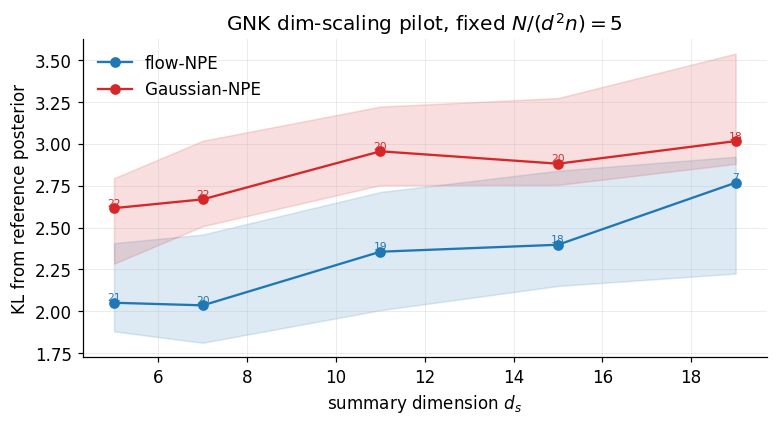

In [12]:
dim = pd.read_csv(DATA / "dim_scaling_pilot_kl_by_d.csv")
finite = dim[(dim.status == "finite_metric") & np.isfinite(dim.theta_kl)].copy()
status_counts = dim.status.value_counts().rename_axis("status").reset_index(name="rows")
display(status_counts)

dim_summary = (finite.groupby(["method", "d_s", "d", "N_sims", "N_over_d2n"])
                    .theta_kl
                    .agg(seed_count="count", median="median",
                         q25=lambda s: np.quantile(s, 0.25),
                         q75=lambda s: np.quantile(s, 0.75))
                    .reset_index())
dim_summary["method_label"] = dim_summary.method.map(METHOD_NAME)
dim_summary["entry"] = dim_summary.apply(
    lambda r: f"{r['median']:.2f} ({int(r.seed_count)})", axis=1)
dim_table = dim_summary.pivot(index="method_label", columns="d_s",
                              values="entry")
dim_table.index.name = "method"
dim_table.columns.name = "summary dimension"
display(dim_table)

fig, ax = plt.subplots(figsize=(7.2, 4.0))
for method, color, label in [("flow_npe", C_FLOW, "flow-NPE"),
                             ("gaussian_npe", C_GAUSS, "Gaussian-NPE")]:
    s = dim_summary[dim_summary.method == method].sort_values("d_s")
    ax.plot(s.d_s, s["median"], "o-", color=color, label=label)
    ax.fill_between(s.d_s, s.q25, s.q75, color=color, alpha=0.15)
    for _, row in s.iterrows():
        ax.text(row.d_s, row["median"], f"{int(row.seed_count)}",
                fontsize=7, ha="center", va="bottom", color=color)
ax.set_xlabel(r"summary dimension $d_s$")
ax.set_ylabel("KL from reference posterior")
ax.set_title(r"GNK dim-scaling pilot, fixed $N/(d^2 n)=5$")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

The main GNK story is now clearer. The paper-grid result still supports the
$N$-scaling claim, but the poor headline Gaussian-NPE fit is not simply a
failure of the Gaussian posterior family. BSL is close to the NUTS reference,
and both robust standardisation and rejection filtering move Gaussian-NPE much
closer to that target. I would present those two checks as internal diagnostics
for now, then decide later whether a short appendix note is useful.

# MA(2)

Before the MA(2) results, a correction. I found that the NUTS reference samples
I had been comparing against for the compatible MA(2) b0 cell were generated
under the older diagonal independent summary likelihood, while the current
driver uses the joint-covariance MVN reference (analytic autocovariance mean,
Bartlett covariance for the sample autocovariances). These are different
references. Under fresh joint-covariance NUTS for all 80 flow seeds at this
cell, the flow median KL drops from 0.667 to 0.019, with q75 0.035 and max
0.131. The headline I was previously carrying ("flow does not converge on MA(2)
compatible") is therefore not supported by current-reference data, and I am
rewriting this section accordingly. The same reference convention applies to
the $\delta_0$ sweep (verified separately), so those numbers are unchanged.

All neural estimators here condition on the three sample autocovariances. So I
compare them to a summary-based reference, not to the exact full-data posterior,
which conditions on information the neural estimators do not see. The reference
is the posterior under a Gaussian summary likelihood with analytic mean (the
population autocovariances at $\theta$) and Bartlett joint covariance for the
sample autocovariances. This is an asymptotic summary-likelihood reference, not
the exact finite-sample posterior for the summaries. For $n \ge 1000$ the
asymptotic and finite-sample summary moments agree closely (max relative
covariance error under 0.5%, mean bias under 0.02 summary-sd units), so the
reference is usable.

In [13]:
ma2_audit = pd.read_csv(DATA / "ma2_b0_reference_audit.csv")
flow_current = pd.read_csv(DATA / "ma2_b0_flow_current_reference_per_seed.csv")
flow_current_summary = pd.read_csv(DATA / "ma2_b0_flow_current_reference_summary.csv")
gauss_current = pd.read_csv(DATA / "ma2_b0_gaussian_current_reference_per_seed.csv")

flow_summary_table = flow_current_summary[
    flow_current_summary.metric.isin(["stored_flow_kl", "current_flow_kl"])
].copy()
display(flow_summary_table[["metric", "n", "median", "q75", "max"]].round(4))

audit_cols = ["seed", "flow_kl_stored", "flow_kl_current",
              "gauss_kl_stored", "gauss_kl_current", "ref_mean_shift_l2"]
display(ma2_audit[audit_cols].round(4))

,metric,n,median,q75,max
0,stored_flow_kl,80,0.6670,1.1132,2.9615
1,current_flow_kl,80,0.0187,0.0350,0.1311


,seed,flow_kl_stored,flow_kl_current,gauss_kl_stored,gauss_kl_current,ref_mean_shift_l2
0,7,0.0121,0.0298,0.0113,NaN,0.0013
1,58,0.3682,0.0057,0.0615,NaN,0.0070
2,22,0.6643,0.0164,0.0912,0.1146,0.0377
3,63,1.1132,0.0271,0.1123,NaN,0.0204
4,69,1.5091,0.0650,0.0553,NaN,0.0525


**Post-timeout status.** The training-pipeline completion issue is separate
from the reference audit above. The exact compatible refresh at $\delta_0=1$
produced complete files for every Gaussian-NPE row, while the largest flow-NPE
cell timed out after producing setup artifacts and no metrics. The 25M flow row
is therefore an operational timeout, not a scientific KL value, and it is not
needed for the current paper-facing MA(2) claim. For Gaussian-NPE, finite KL
medians and `Inf` KL counts are reported separately. MMD stays finite across
the completed rows.

status,complete,nonfinite_kl,partial_training_only
method,,,
flow-NPE,1478,1,137
Gaussian-NPE,1493,123,0


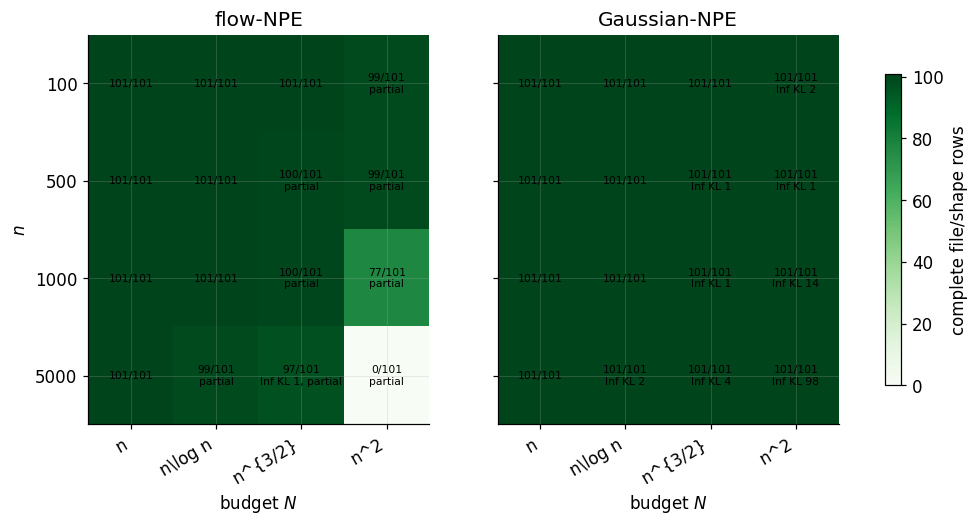

In [14]:
delta1 = pd.read_csv(DATA / "ma2_delta1_refresh.csv")
delta1_audit = pd.read_csv(DATA / "ma2_delta1_refresh_audit.csv")
delta1["budget"] = pd.Categorical(delta1["budget_label"], categories=BUDGETS,
                                  ordered=True)

status_cols = [
    "status_complete_rows", "nonfinite_kl_status_rows", "missing_rows",
    "timed_out_rows", "partial_training_only_rows", "bad_shape_rows",
]
for col in status_cols:
    if col not in delta1.columns:
        delta1[col] = 0

status_overview = (
    delta1_audit.groupby(["method", "status"]).size()
    .unstack(fill_value=0)
    .reindex(["flow_npe", "gaussian_npe"])
)
status_overview.index = status_overview.index.map(METHOD_NAME)
display(status_overview)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), sharey=True)
for ax, method in zip(axes, ["flow_npe", "gaussian_npe"]):
    s = delta1[delta1.method == method].copy()
    mat = s.pivot(index="n_obs", columns="budget", values="complete_rows")
    mat = mat.reindex(index=N_OBS, columns=BUDGETS).fillna(0)
    im = ax.imshow(mat.values, vmin=0, vmax=101, cmap="Greens", aspect="auto")
    ax.set_title(METHOD_NAME[method])
    ax.set_xticks(range(len(BUDGETS)), BUDGET_MATH, rotation=30, ha="right")
    ax.set_yticks(range(len(N_OBS)), [str(n) for n in N_OBS])
    ax.set_xlabel(r"budget $N$")
    if ax is axes[0]:
        ax.set_ylabel(r"$n$")
    for i, n in enumerate(N_OBS):
        for j, budget in enumerate(BUDGETS):
            row = s[(s.n_obs == n) & (s.budget_label == budget)]
            if row.empty:
                label = "0/101\nmissing"
            else:
                row = row.iloc[0]
                label = f"{int(row.complete_rows)}/101"
                extra = []
                if int(row.nonfinite_kl_status_rows):
                    extra.append(f"Inf KL {int(row.infinite_kl_rows)}")
                if int(row.partial_training_only_rows):
                    extra.append("partial")
                if int(row.timed_out_rows):
                    extra.append("timeout")
                if int(row.missing_rows):
                    extra.append(f"missing {int(row.missing_rows)}")
                if extra:
                    label += "\n" + ", ".join(extra[:2])
            ax.text(j, i, label, ha="center", va="center", fontsize=7,
                    color="black")
fig.colorbar(im, ax=axes, shrink=0.8, label="complete file/shape rows")
plt.show()

**Compatible-case current-reference results.** Flow-NPE now has 80 seeds under
the current joint-covariance reference. Gaussian-NPE has five audit seeds (7,
22, 58, 63, 69). That coverage is asymmetric. A full Gaussian-NPE refresh would
take about five hours locally at roughly 300 seconds per rerun and is queued as
a follow-up. At the audit seeds, flow-NPE has lower current-reference KL than
Gaussian-NPE for all five seeds, but both are small.

,method,n_obs,n_sims,stored median KL,current-reference median KL,seeds covered,implication
0,flow-NPE,1000,1000000,0.667,0.019,80,"converges cleanly, old flow stalls headline wa..."
1,Gaussian-NPE,1000,1000000,0.040,0.074,5,"converges, small change from stored, but only ..."


,seed,current flow KL,stored Gaussian KL,current Gaussian KL
0,7,0.0298,0.0113,0.0441
1,22,0.0164,0.0912,0.1146
2,58,0.0057,0.0615,0.0650
3,63,0.0271,0.1123,0.0741
4,69,0.0650,0.0553,0.0878


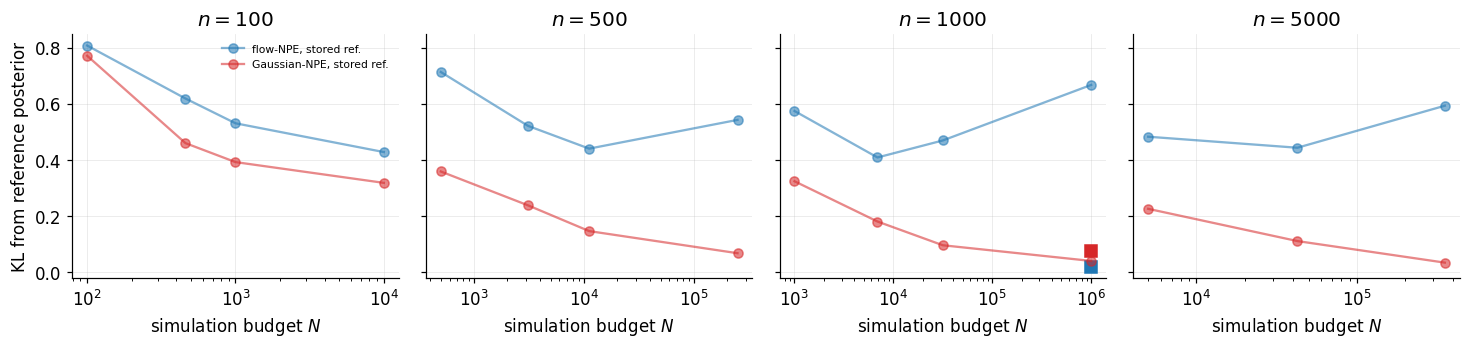

In [15]:
ma2kl = pd.read_csv(DATA / "ma2_b0_kl.csv")
target = ma2kl[(ma2kl.n_obs == 1000) & (ma2kl.n_sims == 1000000)].copy()
before_after = []
for method in ["flow_npe", "gaussian_npe"]:
    row = target[target.method == method].iloc[0]
    current = row.current_reference_kl_median
    n_current = int(row.current_reference_seed_count)
    if method == "flow_npe":
        implication = "converges cleanly, old flow stalls headline was a reference artefact"
    else:
        implication = "converges, small change from stored, but only five audit seeds"
    before_after.append({
        "method": METHOD_NAME[method],
        "n_obs": int(row.n_obs),
        "n_sims": int(row.n_sims),
        "stored median KL": row.kl_median,
        "current-reference median KL": current,
        "seeds covered": n_current,
        "implication": implication,
    })
display(pd.DataFrame(before_after).round(3))

flow_current = pd.read_csv(DATA / "ma2_b0_flow_current_reference_per_seed.csv")
gauss_current = pd.read_csv(DATA / "ma2_b0_gaussian_current_reference_per_seed.csv")
audit_join = gauss_current.merge(
    flow_current[["seed", "current_flow_kl"]],
    on="seed",
    how="left",
)
audit_join = audit_join.rename(columns={
    "gauss_kl_stored": "stored Gaussian KL",
    "gauss_kl_current_recomputed": "current Gaussian KL",
    "current_flow_kl": "current flow KL",
})
display(audit_join[["seed", "current flow KL", "stored Gaussian KL",
                    "current Gaussian KL"]].round(4))

ma2kl_plot = pd.read_csv(DATA / "ma2_b0_kl.csv")
ma2kl_plot = ma2kl_plot.sort_values(["method", "n_obs", "n_sims"])
fig, axes = plt.subplots(1, 4, figsize=(13.5, 3.3), sharey=True)
for ax, n in zip(axes, N_OBS):
    for raw, color, mlabel in [("flow_npe", C_FLOW, "flow-NPE, stored ref."),
                               ("gaussian_npe", C_GAUSS, "Gaussian-NPE, stored ref.")]:
        s = ma2kl_plot[(ma2kl_plot.method == raw) & (ma2kl_plot.n_obs == n)]
        s = s.sort_values("n_sims")
        done = s[(s.n_seeds > 0) & s.kl_median.notna()]
        ax.plot(done.n_sims, done.kl_median, "o-", color=color, alpha=0.55,
                label=mlabel)
        audited = done[(done.current_reference_seed_count > 0)
                       & done.current_reference_kl_median.notna()]
        if not audited.empty:
            ax.plot(audited.n_sims, audited.current_reference_kl_median,
                    "s", color=color, markersize=8,
                    label=METHOD_NAME[raw] + ", current audit")
    ax.set_xscale("log")
    ax.set_title(f"$n = {n}$")
    ax.set_xlabel(r"simulation budget $N$")
axes[0].set_ylabel("KL from reference posterior")
axes[0].legend(frameon=False, fontsize=7)
fig.tight_layout()
plt.show()

**Exact compatible refresh, KL and MMD versus budget.** This uses the
$\delta_0=1$ refresh outputs. It is a completion and stability view, not a
replacement for the b0 reference audit above. Cells with no finite KL or MMD
are explicitly marked at their budget position.

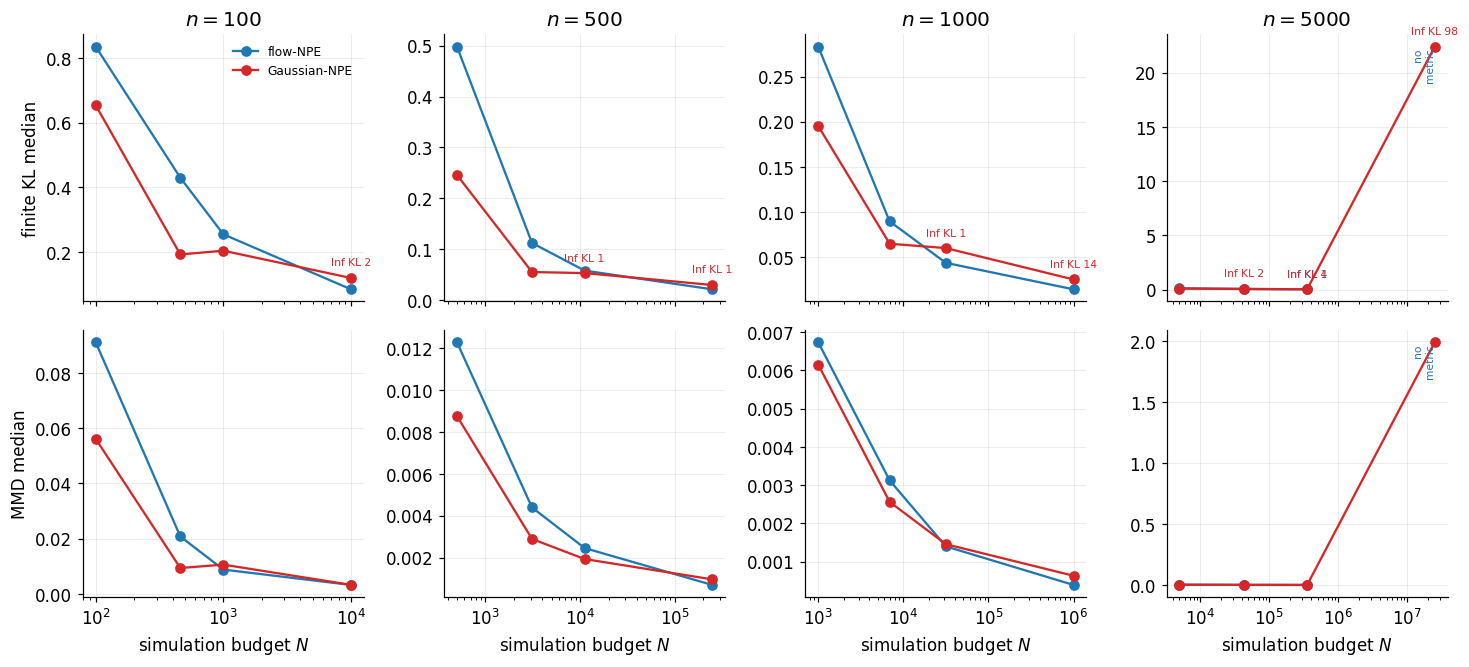

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(13.5, 6.2), sharex="col")
for col, n in enumerate(N_OBS):
    for method, color, label in [("flow_npe", C_FLOW, "flow-NPE"),
                                 ("gaussian_npe", C_GAUSS, "Gaussian-NPE")]:
        s = delta1[(delta1.method == method) & (delta1.n_obs == n)].sort_values("n_sims")
        kl_done = s[(s.finite_kl_rows > 0) & s.finite_kl_median.notna()]
        mmd_done = s[(s.finite_mmd_rows > 0) & s.mmd_median.notna()]
        axes[0, col].plot(kl_done.n_sims, kl_done.finite_kl_median, "o-",
                          color=color, label=label)
        axes[1, col].plot(mmd_done.n_sims, mmd_done.mmd_median, "o-",
                          color=color, label=label)
        missing = s[s.finite_kl_rows == 0]
        for _, row in missing.iterrows():
            axes[0, col].text(row.n_sims, 0.95, "no\nmetric", color=color,
                              fontsize=7, rotation=90, va="top", ha="right",
                              transform=axes[0, col].get_xaxis_transform())
            axes[1, col].text(row.n_sims, 0.95, "no\nmetric", color=color,
                              fontsize=7, rotation=90, va="top", ha="right",
                              transform=axes[1, col].get_xaxis_transform())
        inf_kl = s[s.infinite_kl_rows > 0]
        for _, row in inf_kl.iterrows():
            axes[0, col].annotate(f"Inf KL {int(row.infinite_kl_rows)}",
                                  xy=(row.n_sims, row.finite_kl_median),
                                  xytext=(0, 8), textcoords="offset points",
                                  color=color, fontsize=7, ha="center")
    axes[0, col].set_title(f"$n = {n}$")
    axes[1, col].set_xlabel(r"simulation budget $N$")
    for r in range(2):
        axes[r, col].set_xscale("log")
axes[0, 0].set_ylabel("finite KL median")
axes[1, 0].set_ylabel("MMD median")
axes[0, 0].legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

**Near-compatible lower-boundary summary perturbation.** The $\delta_0$ sweep
is the David Warne meeting follow-up. The meeting concern was that flow-NPE
looked worse than Gaussian-NPE under a near-compatible lower-boundary summary
perturbation. With the staged aggregate below, that exact reading is not
supported. At $\delta_0=0.99$, flow-NPE KL decreases with budget, from about
0.37 at $N=n$ to about 0.012 at $N=n^2$. Gaussian-NPE also decreases, from
about 0.26 to about 0.041. Gaussian-NPE is lower at the two smaller budgets,
while flow-NPE is lower at the two larger budgets.

The reference check still matters. I checked separately that the $\delta_0$
reference convention is the current joint-covariance MVN summary likelihood,
not the older diagonal independent one that caused the compatible case audit
issue, so these numbers are reliable for this reference question. The Gaussian
sweep currently covers only the two endpoints $\{0.01, 0.99\}$, while the flow
sweep covers $\delta_0 \in \{0.01, 0.1, 0.25, 0.5, 0.75, 0.99\}$. Completing
the Gaussian sweep to the four missing $\delta_0$ values is queued.

,flow-NPE,Gaussian-NPE
budget,,
N=n,0.369,0.260
N=n log(n),0.071,0.062
N=n^(3/2),0.038,0.051
N=n^2,0.012,0.031


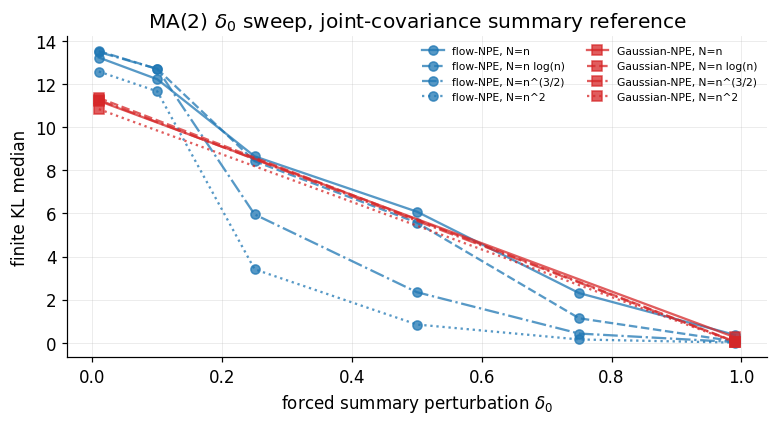

In [17]:
flow_sweep = pd.read_csv(DATA / "ma2_compatibility_flow.csv").copy()
flow_sweep["method"] = "flow_npe"

gauss_raw = pd.read_csv(DATA / "ma2_compatibility_gaussian.csv")
gauss_rows = []
for (delta0, n_obs, n_sims), g in gauss_raw.groupby(["delta0", "n_obs", "n_sims"]):
    vals = g.kl.to_numpy(float)
    if int(n_sims) == 1000:
        budget = "N=n"
    elif int(n_sims) == 6907:
        budget = "N=n log(n)"
    elif int(n_sims) == 31622:
        budget = "N=n^(3/2)"
    else:
        budget = "N=n^2"
    gauss_rows.append({
        "n_obs": int(n_obs),
        "n_sims": int(n_sims),
        "budget_label": budget,
        "delta0": float(delta0),
        "rows": len(vals),
        "finite_kl_rows": int(np.isfinite(vals).sum()),
        "infinite_kl_rows": int(np.isinf(vals).sum()),
        "finite_kl_median": float(np.nanmedian(vals[np.isfinite(vals)])),
        "mmd_median": np.nan,
        "method": "gaussian_npe",
    })
gauss_sweep = pd.DataFrame(gauss_rows)

sweep = pd.concat([flow_sweep, gauss_sweep], ignore_index=True, sort=False)
sweep = sweep[(sweep.n_obs == 1000) & sweep.budget_label.isin(BUDGETS)].copy()
sweep["budget"] = pd.Categorical(sweep.budget_label, categories=BUDGETS,
                                 ordered=True)

mild = sweep[np.isclose(sweep.delta0, 0.99)].copy()
mild_table = mild.pivot_table(index="budget", columns="method",
                              values="finite_kl_median", observed=True)
mild_table = mild_table.reindex(BUDGETS)
mild_table.columns = [METHOD_NAME[c] for c in mild_table.columns]
display(mild_table.round(3))

fig, ax = plt.subplots(figsize=(7.2, 4.0))
for method, color, marker in [("flow_npe", C_FLOW, "o"),
                              ("gaussian_npe", C_GAUSS, "s")]:
    for budget, ls in zip(BUDGETS, ["-", "--", "-.", ":"]):
        s = sweep[(sweep.method == method) & (sweep.budget_label == budget)]
        s = s.sort_values("delta0")
        if s.empty:
            continue
        label = f"{METHOD_NAME[method]}, {budget}"
        ax.plot(s.delta0, s.finite_kl_median, marker=marker, linestyle=ls,
                color=color, alpha=0.75, label=label)
ax.set_xlabel(r"forced summary perturbation $\delta_0$")
ax.set_ylabel("finite KL median")
ax.set_title(r"MA(2) $\delta_0$ sweep, joint-covariance summary reference")
ax.legend(frameon=False, fontsize=7, ncol=2)
fig.tight_layout()
plt.show()

**Severe incompatibility, $\delta_0=0.01$.** The major-incompatibility rows are
still useful as a failure-mode check. Increasing $N$ does not repair a target
that is far outside the model-compatible summary region. This is a different
question from the compatible-case reference audit.

,flow-NPE,Gaussian-NPE
budget,,
N=n,13.232,11.220
N=n log(n),13.533,11.358
N=n^(3/2),13.487,11.263
N=n^2,12.582,10.838


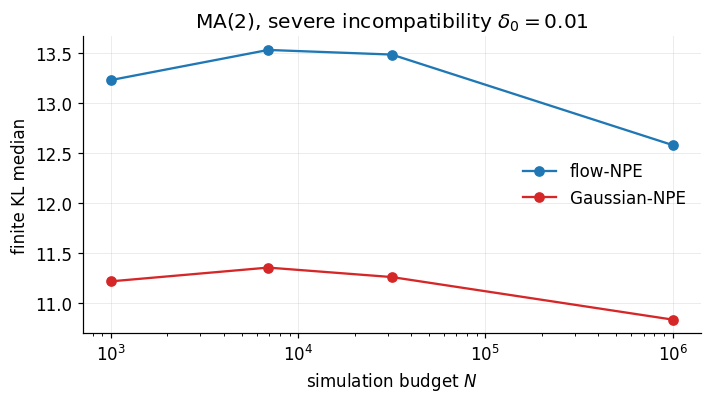

In [18]:
severe = sweep[np.isclose(sweep.delta0, 0.01)].copy()
sev_table = severe.pivot_table(index="budget", columns="method",
                               values="finite_kl_median", observed=True)
sev_table = sev_table.reindex(BUDGETS)
sev_table.columns = [METHOD_NAME[c] for c in sev_table.columns]
display(sev_table.round(3))

fig, ax = plt.subplots(figsize=(6.6, 3.8))
for method, color, label in [("flow_npe", C_FLOW, "flow-NPE"),
                             ("gaussian_npe", C_GAUSS, "Gaussian-NPE")]:
    s = severe[severe.method == method].sort_values("n_sims")
    ax.plot(s.n_sims, s.finite_kl_median, "o-", color=color, label=label)
ax.set_xscale("log")
ax.set_xlabel(r"simulation budget $N$")
ax.set_ylabel("finite KL median")
ax.set_title(r"MA(2), severe incompatibility $\delta_0=0.01$")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

**Posterior overlay at seed 22.** Compatible case, $n=1000$, $N=n^2=1M$.
Flow-NPE closely overlaps the current joint-covariance reference. Gaussian-NPE
is close but slightly shifted in $\theta_1$ and $\theta_2$ with a different
joint correlation. Diagnostic KL values from a 2000-draw subsample at this seed
are 0.016 for flow-NPE and 0.115 for Gaussian-NPE against the current
reference. Compare to the stored `kl.txt` values for the same seed, 0.664 for
flow and 0.091 for Gaussian, measured against the older diagonal-independent
reference. The relative ordering flips.

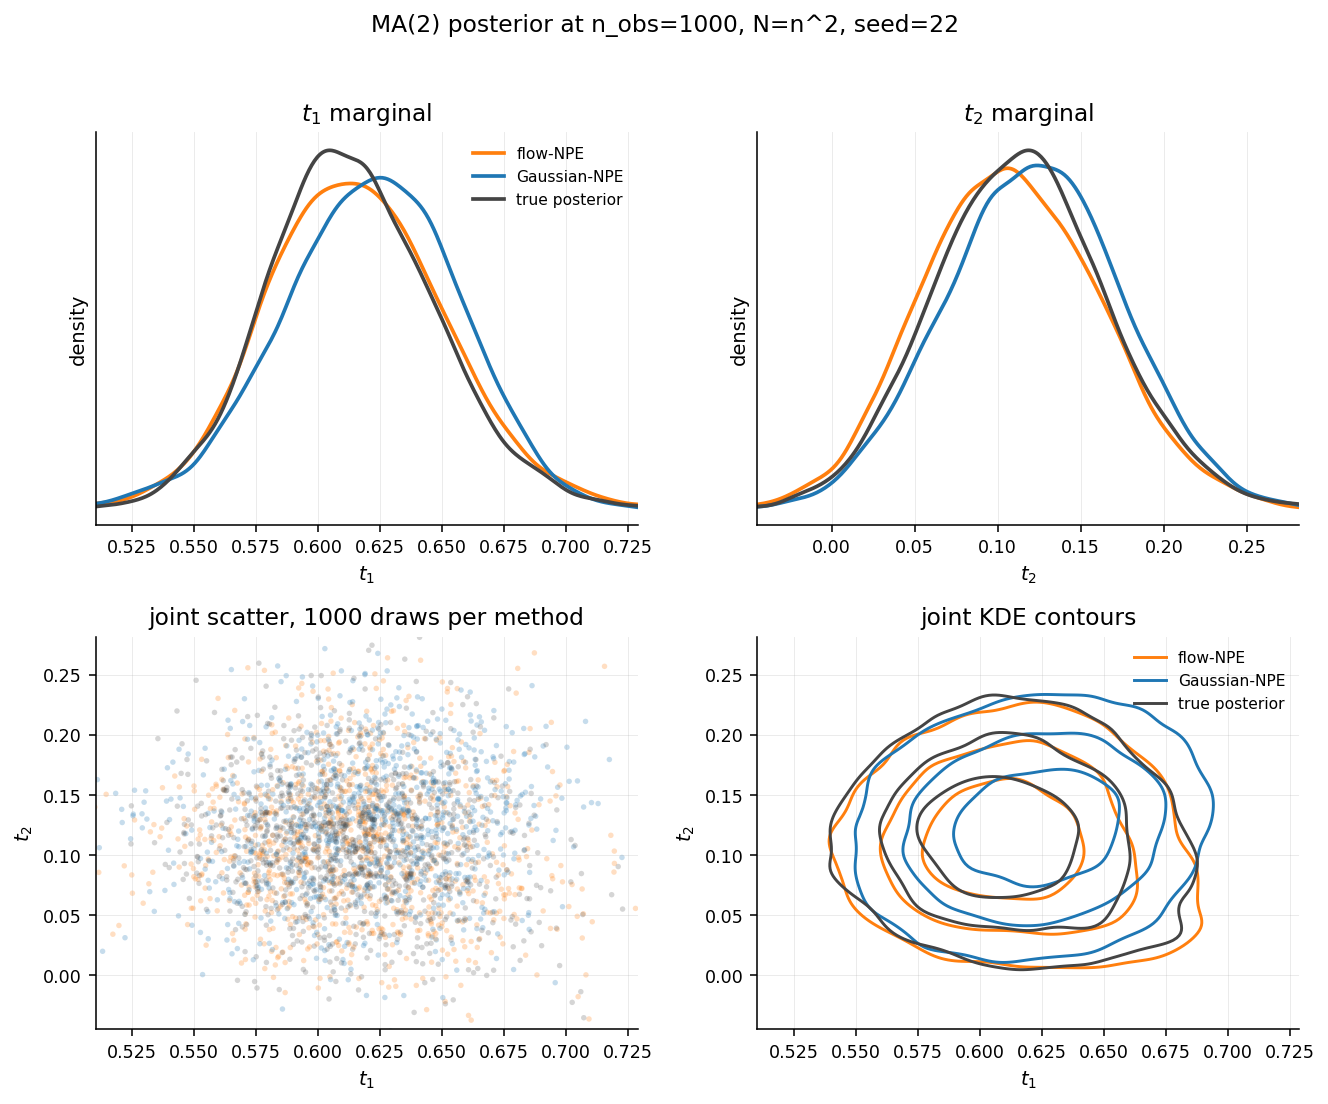

In [19]:
if (DATA / "ma2_posterior_overlay_seed_22.png").exists():
    display(Image(filename=str(DATA / "ma2_posterior_overlay_seed_22.png"), width=720))
else:
    ma2_ov = pd.read_csv(DATA / "ma2_posterior_overlay_seed_22.csv")
    fig, ax = plt.subplots(figsize=(5, 5))
    for method, color in [("true posterior", C_REF), ("flow-NPE", C_FLOW),
                          ("Gaussian-NPE", C_GAUSS)]:
        s = ma2_ov[ma2_ov.method == method]
        ax.scatter(s.t1, s.t2, s=8, alpha=0.25, color=color, label=method)
    ax.set_xlabel(r"$\theta_1$")
    ax.set_ylabel(r"$\theta_2$")
    ax.legend(frameon=False)
    fig.tight_layout()
    plt.show()

Reading the MA(2) results together. The compatible-case headline I had been
carrying ("flow stalls, Gaussian converges cleanly") is not supported under the
current joint-covariance reference. Both methods converge cleanly on compatible
MA(2) b0. Flow-NPE has a slightly lower median KL than Gaussian-NPE at the five
audit seeds where I have an apples-to-apples comparison, but both are small and
the broader 80-seed flow distribution is also small. Under the checked
$\delta_0=0.99$ endpoint, the current staged aggregate does not support a simple
"flow worse than Gaussian" reading. Gaussian-NPE is lower at the smaller
budgets, flow-NPE is lower at the larger budgets, and the missing Gaussian
middle $\delta_0$ values are still queued. The "Gaussian wins on compatible"
headline was an artefact of comparing against a stale diagonal reference. It
does not survive the audit and I am dropping that framing.

# Where to go from here

- MA(2) current-reference coverage. The 80-seed flow refresh is done. The
  Gaussian-NPE current-reference audit covers five seeds, and a full refresh is
  queued as follow-up.
- Flow-NPE coverage at the GNK headline cell. The paired-seed coverage is 65 of
  101 at the moment. A staged-pipeline training recovery is running on the
  remaining 36 seeds and will be evaluated when complete.
- Robust standardisation. This is an internal diagnostic only at the moment. If
  the result holds and the theoretical justification clears, it could appear as
  a brief diagnostic in an appendix.
- Dimension-scaling pilot. The aim is to test $N \gg d^2 n$ directly. The
  result is preliminary.
- Stereological reference upgrade. I am considering the count-factorisation plus
  finer SMC-ABC plan above.
- Repo and data cleanup. Not done yet. HPC access ends around early June.

# Summary

- Stereological remains the clean opening example. Coverage is near nominal at
  practical budgets, with the reference-upgrade plan still open.
- GNK now has two useful diagnostics. BSL agrees with the NUTS reference at the
  checked cell, and both robust standardisation and rejection filtering move
  Gaussian-NPE much closer to that reference.
- MA(2) now has the corrected reference story. The compatible-case flow failure
  does not survive the current-reference audit, and the checked $\delta_0$
  endpoint no longer supports a simple flow-worse reading.